## IMDB Sentiment Analysis 

This project performs sentiment analysis on the IMDB movie review dataset using machine learning techniques.

Objective:
To classify movie reviews as positive or negative based on textual content.

Approach:
- Text preprocessing (cleaning and stopword removal)
- Feature extraction using TF-IDF
- Model training using Logistic Regression and Naive Bayes
- Performance evaluation using accuracy, confusion matrix, and classification report

Outcome:
Logistic Regression achieved higher accuracy and proved more effective for this task.

In [1]:
import pandas as pd
import re
import nltk
import pickle

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/IMDB Dataset.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nSample Data:\n", df.head())

Shape: (50000, 2)

Columns: Index(['review', 'sentiment'], dtype='str')

Sample Data:
                                               review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


## Data Analysis

- The dataset contains 50,000 movie reviews.
- It includes two columns: review (text) and sentiment (label).
- The dataset is balanced, meaning equal positive and negative samples.

In [3]:
print("\nSentiment Distribution:\n", df['sentiment'].value_counts())
print("\nMissing Values:\n", df.isnull().sum())


Sentiment Distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing Values:
 review       0
sentiment    0
dtype: int64


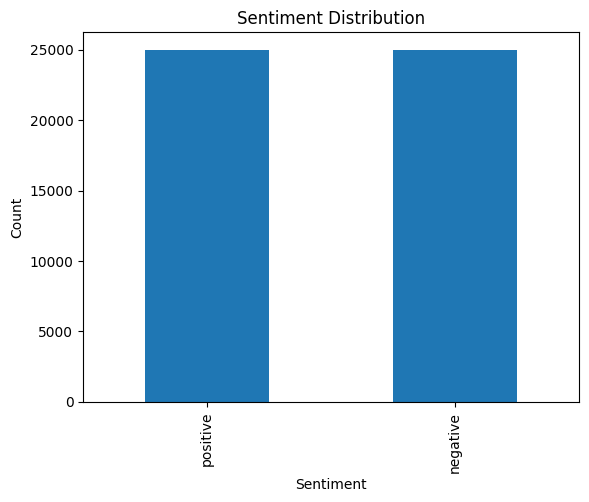

In [4]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### Analysis:

The dataset shows an equal distribution of positive and negative reviews (25,000 each). 
This indicates that the dataset is **perfectly balanced**, which is critical for training reliable classification models.

In imbalanced datasets, models tend to favor the majority class, leading to misleading accuracy. 
However, in this case, accuracy becomes a **trustworthy metric** since both classes are equally represented.

This balance ensures that performance differences between Logistic Regression and Naive Bayes 
are due to model capability rather than data bias.

## Text Preprocessing

Raw text data contains noise such as HTML tags, punctuation, and common words.

The following steps are applied:
- Convert text to lowercase
- Remove HTML tags
- Remove punctuation and numbers
- Remove extra spaces
- Remove stopwords

This improves model performance by keeping only meaningful words.

In [5]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/habibshah/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
df['clean_review'] = df['review'].apply(clean_text)

print("Original:\n", df['review'][0])
print("\nCleaned:\n", df['clean_review'][0])

Original:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

## TF-IDF Vectorization

TF-IDF (Term Frequency - Inverse Document Frequency) converts text into numerical form.

- Term Frequency (TF): Measures how often a word appears in a review
- Inverse Document Frequency (IDF): Reduces importance of common words

This ensures that:
- Common words like "the", "is" have low importance
- Important words like "excellent", "worst" have higher importance

This improves model performance by focusing on meaningful features.

In [7]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_review'])

y = df['sentiment']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 5000)
y shape: (50000,)


### Analysis:

TF-IDF transforms textual data into numerical features while reducing the impact of common words 
and emphasizing informative words.

This is crucial because raw text cannot be directly used by machine learning models. 
By applying TF-IDF, we convert each review into a high-dimensional sparse vector, 
allowing models to identify patterns in word usage.

This representation is particularly effective for Logistic Regression, 
which performs well on high-dimensional sparse data.

## Train-Test Split

The dataset is split into:
- 80% training data
- 20% testing data

This ensures the model is evaluated on unseen data.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (40000, 5000)
Test shape: (10000, 5000)


## Model Training

### Analysis:

Two models were selected for comparison:

- **Logistic Regression**: Suitable for high-dimensional sparse data like TF-IDF features. 
  It learns weighted relationships between words and sentiment.

- **Naive Bayes**: Assumes independence between words, making it fast but less realistic 
  for natural language, where word relationships matter.

This comparison helps evaluate whether a simple probabilistic model (Naive Bayes) 
can compete with a more flexible linear model (Logistic Regression).

In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

nb = MultinomialNB()
nb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [10]:
lr_preds = lr.predict(X_test)
nb_preds = nb.predict(X_test)

## Feature Importance

Logistic Regression assigns weights to each word.

- Positive weights → push prediction towards positive sentiment
- Negative weights → push prediction towards negative sentiment

This helps us understand how the model makes decisions.


In [11]:
feature_names = vectorizer.get_feature_names_out()
coefs = lr.coef_[0]

top_positive = sorted(zip(coefs, feature_names))[-10:]
top_negative = sorted(zip(coefs, feature_names))[:10]

print("Top Positive Words:")
for coef, word in top_positive:
    print(word, ":", round(coef, 3))

print("\nTop Negative Words:")
for coef, word in top_negative:
    print(word, ":", round(coef, 3))

Top Positive Words:
favorite : 4.237
loved : 4.269
hilarious : 4.337
brilliant : 4.736
best : 4.791
amazing : 4.81
wonderful : 4.901
perfect : 5.07
excellent : 6.632
great : 7.086

Top Negative Words:
worst : -10.225
waste : -7.935
awful : -7.357
bad : -7.235
boring : -6.832
terrible : -5.906
poor : -5.866
nothing : -5.333
dull : -5.25
poorly : -5.139


### Analysis:

The model assigns positive weights to words associated with positive sentiment 
(e.g., "excellent", "great") and negative weights to words associated with negative sentiment 
(e.g., "worst", "awful").

This confirms that the model is learning meaningful linguistic patterns rather than random noise.

Additionally, the magnitude of weights indicates the strength of influence each word has on prediction, 
providing interpretability to the model's decisions.

### Deeper Insight:

The presence of strong sentiment words like "excellent", "great", "worst", and "awful" 
indicates that the model relies heavily on explicit emotional language.

However, this also reveals a limitation:
The model may struggle with **sarcasm, subtle tone, or context-dependent sentiment** 
(e.g., "not bad" or "could have been better").

This highlights the limitation of TF-IDF + linear models, 
which treat words independently rather than understanding full sentence meaning.

## Model Evaluation

Models are evaluated using:
- Accuracy Score
- Confusion Matrix
- Classification Report

This helps measure performance and compare models.

In [12]:
lr_acc = accuracy_score(y_test, lr_preds)
nb_acc = accuracy_score(y_test, nb_preds)

print("Logistic Regression Accuracy:", lr_acc)
print("Naive Bayes Accuracy:", nb_acc)

Logistic Regression Accuracy: 0.8919
Naive Bayes Accuracy: 0.8553


## Model Comparison Insight

### Analysis:

Although the accuracy difference between Logistic Regression (~89%) and Naive Bayes (~85%) may seem small, 
the confusion matrix shows that this improvement is consistent across both classes.

Logistic Regression reduces total errors significantly, particularly false negatives, 
which are critical in sentiment analysis because misclassifying positive reviews harms user experience.

This suggests that Logistic Regression is not just statistically better, 
but also practically more useful in real-world applications.

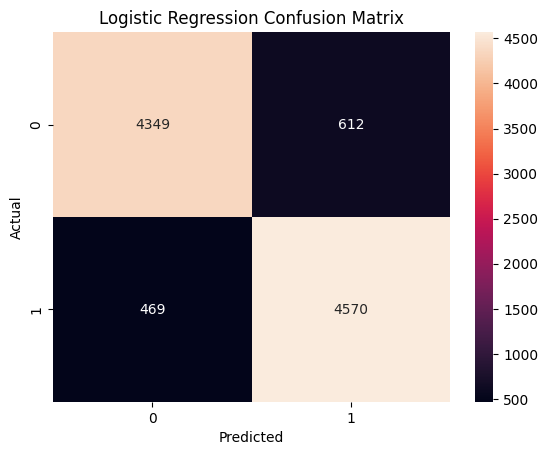

In [13]:
lr_cm = confusion_matrix(y_test, lr_preds)

plt.figure()
sns.heatmap(lr_cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

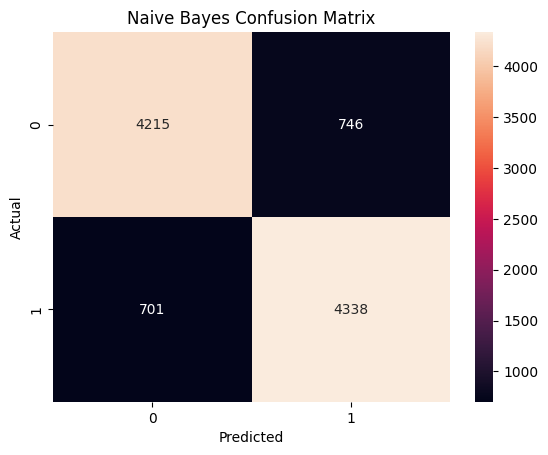

In [14]:
nb_cm = confusion_matrix(y_test, nb_preds)

plt.figure()
sns.heatmap(nb_cm, annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Confusion Matrix Interpretation

### Analysis:

A deeper comparison of confusion matrices reveals important differences:

- Logistic Regression produces **fewer false positives (612 vs 746)** and **fewer false negatives (469 vs 701)** than Naive Bayes.
- This means Logistic Regression is better at correctly identifying both positive and negative reviews.

Notably, Naive Bayes struggles more with false negatives, meaning it incorrectly classifies positive reviews as negative more often.

This indicates that Naive Bayes fails to capture contextual sentiment, while Logistic Regression better models word importance and relationships.

Therefore, Logistic Regression is not just more accurate — it is more reliable across both classes.

In [15]:
print("Logistic Regression Report:\n", classification_report(y_test, lr_preds))
print("Naive Bayes Report:\n", classification_report(y_test, nb_preds))

Logistic Regression Report:
               precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4961
    positive       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Naive Bayes Report:
               precision    recall  f1-score   support

    negative       0.86      0.85      0.85      4961
    positive       0.85      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



### Final Conclusion:

This analysis demonstrates that while both Logistic Regression and Naive Bayes are effective for sentiment classification, 
their performance differs significantly in error behavior.

Logistic Regression consistently outperforms Naive Bayes by reducing both false positives and false negatives, 
making it more reliable for real-world deployment.

The results also highlight a key trade-off:
- Simpler models like Naive Bayes are faster but less accurate
- More flexible models like Logistic Regression capture patterns better but require more computation

Despite strong performance, the model is still limited by its inability to understand context, sarcasm, and word dependencies.

Therefore, while Logistic Regression is the best choice among the tested models, 
more advanced approaches such as deep learning models would be required for further improvement.

## Real-World Applications

This model can be applied in:

- Customer review analysis
- Social media sentiment monitoring
- Product feedback systems

It can automatically classify large volumes of text data into positive and negative sentiments.

## Future Improvements

Although the model performs well, several improvements can enhance performance:

- Use bi-grams and tri-grams to capture phrases like "not good" or "very bad"
- Apply lemmatization instead of simple cleaning to preserve word meaning
- Perform hyperparameter tuning (GridSearchCV) for optimal model settings
- Try advanced models like LSTM or BERT for deeper contextual understanding
- Use cross-validation instead of a single train-test split for more reliable evaluation

These improvements can further increase accuracy and robustness.

In [16]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    prediction = lr.predict(vector)[0]
    return prediction

In [19]:
print(predict_sentiment("Best movie"))
print(predict_sentiment("good movie"))

positive
positive


In [18]:
with open("../model/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

### Practical Impact:

In real-world systems such as product reviews or social media monitoring:

- Reducing false negatives ensures positive feedback is not ignored
- Reducing false positives prevents misleading sentiment classification

Since Logistic Regression minimizes both types of errors, 
it is better suited for deployment in applications where decision accuracy directly impacts user trust.